In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from operator import add
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

llm = ChatGroq(
    model = "openai/gpt-oss-20b",
    temperature = 0
)

In [ ]:
## structured output schema
class Feedback(BaseModel):
    score: int = Field(ge=0,le=10,description="score from 0-10")
    feedback: str = Field(description = 'Detailed Feedback on essay')


    


In [4]:
## convert normal llm into structured llm
structured_llm = llm.with_structured_output(Feedback)

In [5]:
##state
class State(TypedDict):

    essay: str

    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str

    ## reducer

    score: Annotated[list[int],add]
    avg_score: float


In [6]:
##node function 1
def language_feedback(state: State):
    prompt = f"""
    Evaluate ONLY the LANGUAGE of this essay.

    Focus on:
    - Grammar
    - Vocabulary
    - Sentence structure
    - Word choice

    Give a score from 0 to 10.

    Essay: {state['essay']} """

    response = structured_llm.invoke(prompt)

    return{
        'language_feedback': response.feedback,'score': [response.score]
    }


In [7]:
## node 2 

def analysis_feedback(state: State):

    prompt = f"""
    Evaluate ONLY the ANALYSIS of this essay.

    Focus on:
    - Quality of ideas
    - Arguments
    - Depth
    - Logical reasoning
    - Supporting points

    Give a score from 0 to 10.

    Essay:
    {state["essay"]}
    """

    response = structured_llm.invoke(prompt)

    return {
        "analysis_feedback": response.feedback,
        "score": [response.score]
    }


In [8]:
## node 3 function


def clarity_feedback(state: State):

    prompt = f"""
    Evaluate ONLY the CLARITY of this essay.

    Focus on:
    - How clearly ideas are communicated
    - Organization
    - Readability
    - Ease of understanding

    Give a score from 0 to 10.

    Essay:
    {state["essay"]}
    """

    response = structured_llm.invoke(prompt)

    return {
        "clarity_feedback": response.feedback,
        "score": [response.score]
    }



In [12]:
## node 4 function
def avg_score(state: State):
    average = sum(state['score'])/len(state['score'])

    return{
        "avg_score": round(average,2)
    }

In [15]:
graph = StateGraph(State)

graph.add_node(
    "language_feedback",
    language_feedback
)

graph.add_node(
    "analysis_feedback",
    analysis_feedback
)

graph.add_node(
    "clarity_feedback",
    clarity_feedback
)

graph.add_node(
    "calculate_average",
    avg_score
)

## edges

graph.add_edge(
    START,
    "language_feedback"
)

graph.add_edge(
    START,
    "analysis_feedback"
)

graph.add_edge(
    START,
    "clarity_feedback"
)

graph.add_edge(
    "language_feedback",
    "calculate_average"
)

graph.add_edge(
    "analysis_feedback",
    "calculate_average"
)

graph.add_edge(
    "clarity_feedback",
    "calculate_average"
)


graph.add_edge(
    "calculate_average",
    END
)


workflow = graph.compile()

In [23]:
essay = """
My university life is very difficult and also it is very good experience for me because I learn many thing from university. When I first come in university I was very confuse and I don't know where is my class and what teacher will teach us. The university are very big and there is many student which are coming from different city.

Everyday I goes university at 8 clock in morning but sometimes I am late because the bus are not come on time. When I reach university my friends was already sitting in class and teacher teach the lecture. I was feeling very bad because I miss many important things. My teacher always tell us you should comes on time but I doesn't always follow this advice.

In university I have many subject like programming, database, artificial intelligence and software engineering. Programming are very difficult for me because there is many codes and I doesn't understand them quickly. Sometimes I try to learn coding but after some time I gets bored and start using my mobile phone. My English is also not very good because I am make many mistake when I speak with other peoples.

My friends is very helpful and they always helps me when I have problem. We studies together and discuss about our assignments. Sometimes we was studying in library but mostly we are sitting in cafeteria and talking about unnecessary things. Yesterday we was discussing our project but one of my friend say that he don't know nothing about the project.

University teachers gives us many assignments and these assignments makes students very stress. Some assignments is easy but some of them are extremely difficult and I don't knows how to complete it. When deadline is near, students start working very fastly and they makes many errors. I also submit my assignments late many times because I was not managing my time proper.

Another problem is that university life are expensive. Students needs money for transport, food, books and other things. The fees is also very high and sometimes it make students worried. If university provide more facilities for students it will be more better for everyone.

In conclusion my university life have many good and bad things. I learn new knowledge, meet new peoples and make many friends. But I also face many problems and difficulties. I wants to become a successful person in future and I will try my best for achieve my goals. University is important because it teach us not only education but also how we lives our life and how we become responsible person.
"""



result = workflow.invoke({
'essay': essay
})
result

{'essay': "\nMy university life is very difficult and also it is very good experience for me because I learn many thing from university. When I first come in university I was very confuse and I don't know where is my class and what teacher will teach us. The university are very big and there is many student which are coming from different city.\n\nEveryday I goes university at 8 clock in morning but sometimes I am late because the bus are not come on time. When I reach university my friends was already sitting in class and teacher teach the lecture. I was feeling very bad because I miss many important things. My teacher always tell us you should comes on time but I doesn't always follow this advice.\n\nIn university I have many subject like programming, database, artificial intelligence and software engineering. Programming are very difficult for me because there is many codes and I doesn't understand them quickly. Sometimes I try to learn coding but after some time I gets bored and st

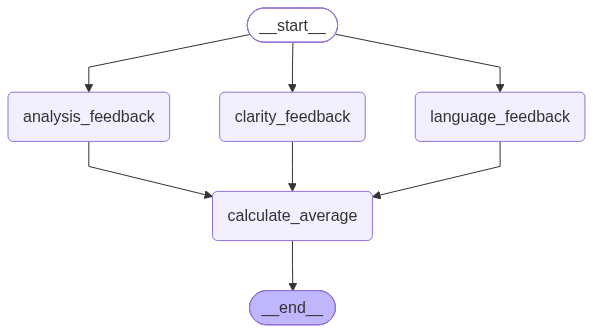

In [24]:
from IPython.display import Image, display

display(
    Image(
        workflow.get_graph().draw_mermaid_png()
    )
)